<a href="https://colab.research.google.com/github/jeanbaptistehabimanaMIT2026/MIT-projects-2026/blob/main/M05688_2026_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**I Start my project by importing library of pandas that helps: **
  
  1. For loading dataset,
  2. For exploring dataset,
  3. For cleaning dataset,
  4. For analysing and saving dataset.


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/student_performance.csv')



### Dataset Overview: Shape, Data Types, Missing Values, and Duplicates

In [ ]:
# 1. Report the shape (rows and columns) of the dataset.
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 253 rows, 15 columns


In [ ]:
# 2. List all column data types.
print("\nColumn Data Types:")
display(df.dtypes)


Column Data Types:


,0
StudentID,object
School,object
District,object
Gender,object
Age,int64
StudyHoursPerDay,float64
AbsenceDays,int64
ParentEducation,object
HasInternet,int64
AttendsTutoring,int64


#### Data Type Assessment:
- `StudentID`: `object` is appropriate as it's a unique identifier.
- `School`, `District`, `Gender`: `object` is appropriate for categorical text data.
- `Age`: `int64` is appropriate for numerical age.
- `Class`: `int64` is appropriate for class level.
- `StudyHours`: `object` is inappropriate; it should be numerical. Values like '3-5' suggest it needs cleaning.
- `Attendance`: `int64` is appropriate for numerical count of attendance.
- `PreviousScores`: `int64` is appropriate for numerical scores.
- `ExtracurricularActivities`: `object` is appropriate for boolean-like text ('Yes', 'No').
- `Tutoring`: `object` is appropriate for boolean-like text ('Yes', 'No').
- `Sports`: `object` is appropriate for boolean-like text ('Yes', 'No').
- `Grades`: `float64` is appropriate for numerical grades, even if some are represented as letters.
- `GPA`: `float64` is appropriate for numerical GPA.
- `PerformanceCategory`: `object` is appropriate for categorical text data.

**Actionable Insight:** The `StudyHours` column needs to be converted to a numerical type after handling the non-numeric entries. Other `object` types may need standardization (e.g., casing).

In [ ]:
# 3. Identify and count ALL missing values across every column.
print("\nMissing Values Count:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])


Missing Values Count:


,0
StudyHoursPerDay,6
ParentEducation,26
SleepHours,4


In [ ]:
# 4. Identify ALL duplicate rows and report which rows are affected.
duplicate_rows = df[df.duplicated(keep=False)]
print(f"\nNumber of Duplicate Rows: {len(duplicate_rows)}")
if not duplicate_rows.empty:
    print("Affected Duplicate Rows (showing all instances of duplicates):")
    display(duplicate_rows.sort_values(by=list(df.columns)))


Number of Duplicate Rows: 6
Affected Duplicate Rows (showing all instances of duplicates):


,StudentID,School,District,Gender,Age,StudyHoursPerDay,AbsenceDays,ParentEducation,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore,GradeLabel
20,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
250,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
55,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
251,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
112,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A
252,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A


### 5. Identifying Outliers Across Numeric Columns

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
outliers_dict = {}

print("**Outlier Detection (using IQR Method):**\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not col_outliers.empty:
        outliers_dict[col] = col_outliers
        print(f"Outliers found in column: **{col}**")
        display(col_outliers[[col]])
        print(f"*Explanation for {col}:* These values fall significantly outside the interquartile range (1.5 * IQR rule). Further investigation is needed to determine if they are genuine extreme values (e.g., a student with exceptionally high study hours) or data entry errors (e.g., a typo in age). For instance, an 'Age' of 10 could be a data entry error if the typical age range for this dataset is 15-19, or a genuine but unusual case. Similarly, very high 'FinalScore' could be an excellent performance or a typo. These would typically be reviewed with domain experts.")
        print("\n")

if not outliers_dict:
    print("No significant outliers detected using the IQR method in any numeric column.")

**Outlier Detection (using IQR Method):**

Outliers found in column: **StudyHoursPerDay**


,StudyHoursPerDay
12,25.0


*Explanation for StudyHoursPerDay:* These values fall significantly outside the interquartile range (1.5 * IQR rule). Further investigation is needed to determine if they are genuine extreme values (e.g., a student with exceptionally high study hours) or data entry errors (e.g., a typo in age). For instance, an 'Age' of 10 could be a data entry error if the typical age range for this dataset is 15-19, or a genuine but unusual case. Similarly, very high 'FinalScore' could be an excellent performance or a typo. These would typically be reviewed with domain experts.


Outliers found in column: **AbsenceDays**


,AbsenceDays
47,180


*Explanation for AbsenceDays:* These values fall significantly outside the interquartile range (1.5 * IQR rule). Further investigation is needed to determine if they are genuine extreme values (e.g., a student with exceptionally high study hours) or data entry errors (e.g., a typo in age). For instance, an 'Age' of 10 could be a data entry error if the typical age range for this dataset is 15-19, or a genuine but unusual case. Similarly, very high 'FinalScore' could be an excellent performance or a typo. These would typically be reviewed with domain experts.


Outliers found in column: **FinalScore**


,FinalScore
89,150.0


*Explanation for FinalScore:* These values fall significantly outside the interquartile range (1.5 * IQR rule). Further investigation is needed to determine if they are genuine extreme values (e.g., a student with exceptionally high study hours) or data entry errors (e.g., a typo in age). For instance, an 'Age' of 10 could be a data entry error if the typical age range for this dataset is 15-19, or a genuine but unusual case. Similarly, very high 'FinalScore' could be an excellent performance or a typo. These would typically be reviewed with domain experts.




### 6. Identifying Inconsistencies in Categorical/Text Columns

In [ ]:
text_categorical_cols = df.select_dtypes(include='object').columns

print("**Reviewing Unique Values for Inconsistencies in Categorical/Text Columns:**\n")

for col in text_categorical_cols:
    print(f"Column: **{col}**")
    unique_values = df[col].unique()
    display(unique_values)

    if col == 'ParentEducation':
        print("""*Observation for ParentEducation:*
These values show wording inconsistencies like 'Secondary' vs 'Secondary School', and 'Primary School' vs 'Primary'. There is also a casing inconsistency: 'University' and 'UNIVERSITY' appear as if they were two different categories, even though they represent the same qualification level. All of these need to be standardized during cleaning.""")
    elif col == 'School':
        print("""*Observation for School:*
'Kigali High School' and 'kigali high school' appear as separate values because of inconsistent capitalisation, even though they refer to the same school. This needs to be standardized (e.g. with title casing) so this school is not undercounted or split into two groups during analysis.""")
    elif col == 'Gender':
        print("""*Observation for Gender:*
'Female' and 'female' are the same category split by casing, and 'M' is an abbreviation of 'Male' rather than a genuinely different value. Left as-is, this would turn 2 real categories into 4, so these need to be standardized during cleaning.""")
    elif col in ['District', 'GradeLabel']:
        print("*Observation:*\nThese values are consistent — no casing, spelling, or abbreviation issues found.")
    elif col == 'StudentID':
        print("*Observation:*\nStudentID values should be unique. Duplicates were identified and will be handled during cleaning. No other inconsistencies in format or casing are immediately apparent.")
    else:
        print("*Observation:*\nReview for inconsistent casing, extra spaces, abbreviations, or misspellings.")
    print("\n---\n")


**Reviewing Unique Values for Inconsistencies in Categorical/Text Columns:**

Column: **StudentID**


array(['STU0001', 'STU0002', 'STU0003', 'STU0004', 'STU0005', 'STU0006',
       'STU0007', 'STU0008', 'STU0009', 'STU0010', 'STU0011', 'STU0012',
       'STU0013', 'STU0014', 'STU0015', 'STU0016', 'STU0017', 'STU0018',
       'STU0019', 'STU0020', 'STU0021', 'STU0022', 'STU0023', 'STU0024',
       'STU0025', 'STU0026', 'STU0027', 'STU0028', 'STU0029', 'STU0030',
       'STU0031', 'STU0032', 'STU0033', 'STU0034', 'STU0035', 'STU0036',
       'STU0037', 'STU0038', 'STU0039', 'STU0040', 'STU0041', 'STU0042',
       'STU0043', 'STU0044', 'STU0045', 'STU0046', 'STU0047', 'STU0048',
       'STU0049', 'STU0050', 'STU0051', 'STU0052', 'STU0053', 'STU0054',
       'STU0055', 'STU0056', 'STU0057', 'STU0058', 'STU0059', 'STU0060',
       'STU0061', 'STU0062', 'STU0063', 'STU0064', 'STU0065', 'STU0066',
       'STU0067', 'STU0068', 'STU0069', 'STU0070', 'STU0071', 'STU0072',
       'STU0073', 'STU0074', 'STU0075', 'STU0076', 'STU0077', 'STU0078',
       'STU0079', 'STU0080', 'STU0081', 'STU0082', 

*Observation:*
StudentID values should be unique. Duplicates were identified and will be handled during cleaning. No other inconsistencies in format or casing are immediately apparent.

---

Column: **School**


array(['Kigali High School', 'École Belge', 'FAWE Girls',
       'Green Hills Academy', 'Lycée de Kigali', 'kigali high school'],
      dtype=object)

*Observation for School:*
'Kigali High School' and 'kigali high school' appear as separate values because of inconsistent capitalisation, even though they refer to the same school. This needs to be standardized (e.g. with title casing) so this school is not undercounted or split into two groups during analysis.

---

Column: **District**


...

*Observation for Gender:*
'Female' and 'female' are the same category split by casing, and 'M' is an abbreviation of 'Male' rather than a genuinely different value. Left as-is, this would turn 2 real categories into 4, so these need to be standardized during cleaning.

---

Column: **ParentEducation**


array(['Primary', 'Secondary', 'University', nan, 'UNIVERSITY'],
      dtype=object)

*Observation for ParentEducation:*
These values show wording inconsistencies like 'Secondary' vs 'Secondary School', and 'Primary School' vs 'Primary'. There is also a casing inconsistency: 'University' and 'UNIVERSITY' appear as if they were two different categories, even though they represent the same qualification level. All of these need to be standardized during cleaning.

---

Column: **GradeLabel**


array(['C', 'Fail', 'A', 'B', 'D'], dtype=object)

*Observation:*
These values are consistent — no casing, spelling, or abbreviation issues found.

---



## Continuing Data Cleaning (Task A2)

## 1.Handle all missing values — justify your choice of strategy (drop, mean, median, or mode) for each column.

In [ ]:
# Problem: Missing values were identified in task 1 in 'StudyHoursPerDay' (6), 'ParentEducation' (26), and 'SleepHours' (4).
# How it's fixed: 'StudyHoursPerDay' and 'SleepHours' (numerical) will be filled with their respective median values. 'ParentEducation' (categorical) will be filled with its mode.
# Why this approach: Median imputation is chosen for numerical columns because it is robust to outliers and preserves the distribution better than the mean if the data is skewed. Mode imputation for categorical data is appropriate as it fills missing entries with the most frequent category, maintaining the overall distribution of the categorical variable.

print("**Missing values before imputation:**")
missing_values_before = df.isnull().sum()
display(missing_values_before[missing_values_before > 0])

# Impute numerical columns with median
for col in ['StudyHoursPerDay', 'SleepHours']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Impute categorical column with mode
if df['ParentEducation'].isnull().any():
    mode_val = df['ParentEducation'].mode()[0]
    df['ParentEducation'] = df['ParentEducation'].fillna(mode_val)
    print(f"Filled missing values in 'ParentEducation' with mode: {mode_val}")

print("\n**Missing values after imputation:**")
missing_values_after = df.isnull().sum()
display(missing_values_after[missing_values_after > 0])

**Missing values before imputation:**


,0
StudyHoursPerDay,6
ParentEducation,26
SleepHours,4


Filled missing values in 'StudyHoursPerDay' with median: 4.4
Filled missing values in 'SleepHours' with median: 7.0
Filled missing values in 'ParentEducation' with mode: Secondary

**Missing values after imputation:**


,0


### 2. Removing Duplicate Rows state how many were removed and confirm 0 duplicates remain

In [ ]:
# Problem: 6 duplicate rows were identified in Task A1, and the previous verification showed they still exist.
# How it's fixed: I will use `df.drop_duplicates(inplace=True)` to remove all identical rows.
# Why this approach: Duplicate rows introduce bias and inflate dataset size without adding new information. Removing them ensures each observation is unique, which is crucial for accurate analysis.

print("**Before removing duplicate rows:**")
initial_rows = df.shape[0]
duplicate_rows_before = df[df.duplicated(keep=False)]
print(f"Number of Duplicate Rows: {len(duplicate_rows_before)}")
if not duplicate_rows_before.empty:
    display(duplicate_rows_before.sort_values(by=list(df.columns)))

df.drop_duplicates(inplace=True)
cleaned_rows = df.shape[0]

print(f"\n**After removing duplicate rows:**")
print(f"Removed {initial_rows - cleaned_rows} duplicate rows.")
print(f"New dataset shape: {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"Number of Duplicate Rows remaining: {len(df[df.duplicated(keep=False)])}")

**Before removing duplicate rows:**
Number of Duplicate Rows: 6


,StudentID,School,District,Gender,Age,StudyHoursPerDay,AbsenceDays,ParentEducation,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore,GradeLabel
20,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
250,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
55,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
251,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
112,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A
252,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A



**After removing duplicate rows:**
Removed 3 duplicate rows.
New dataset shape: 250 rows, 15 columns.
Number of Duplicate Rows remaining: 0


### 3. Standardizing Categorical Inconsistencies (`ParentEducation`)

In [ ]:
# Problem: in Task 1 the 'ParentEducation' column has inconsistent values: wording inconsistencies
# ('Secondary' vs 'Secondary School', 'Primary School' vs 'Primary') AND a casing inconsistency
# ('University' vs 'UNIVERSITY') that represent the same real-world category.
# How it's fixed: I standardize 'Secondary' to 'Secondary School', 'Primary School' to 'Primary',
# and fold 'UNIVERSITY' into 'University' using .str.title() so casing can never re-introduce a
# duplicate category, however the raw data happens to be typed.
# Why this approach: Standardizing ensures that all entries for the same category are uniformly
# represented, preventing miscounts, incorrect groupings, or (as with 'University'/'UNIVERSITY')
# duplicated one-hot encoded columns during modelling. Choosing a concise form ('Primary') while
# elaborating 'Secondary School' creates a clear hierarchy; .str.title() is applied last so it
# cannot undo the 'Secondary School' / 'Primary' wording choices already made.

print("**Before standardizing ParentEducation:**")
display(df['ParentEducation'].unique())

df['ParentEducation'] = df['ParentEducation'].replace('Secondary', 'Secondary School')
df['ParentEducation'] = df['ParentEducation'].replace('Primary School', 'Primary')
df['ParentEducation'] = df['ParentEducation'].str.title()

print("\n**After standardizing ParentEducation:**")
display(df['ParentEducation'].unique())


**Before standardizing ParentEducation:**


array(['Primary', 'Secondary School', 'University'], dtype=object)


**After standardizing ParentEducation:**


array(['Primary', 'Secondary School', 'University'], dtype=object)

## Standardizing Inconsistent Text Values :School column

In [ ]:
# Problem: The 'School' column has inconsistent casing (e.g., 'Kigali High School' and 'kigali high school').
# How it's fixed: I will convert all entries in the 'School' column to title case to ensure uniformity.
# Why this approach: Title casing is a standard way to normalize string data for proper names, ensuring that all variations of the same school name are treated as identical.

print("**Before standardizing School names:**")
display(df['School'].unique())

df['School'] = df['School'].str.title()

print("\n**After standardizing School names:**")
display(df['School'].unique())

**Before standardizing School names:**


array(['Kigali High School', 'École Belge', 'FAWE Girls',
       'Green Hills Academy', 'Lycée de Kigali', 'kigali high school'],
      dtype=object)


**After standardizing School names:**


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)

### Standardize Gender column

In [ ]:
# Problem: The 'Gender' column has inconsistent values: 'Female' and 'female' (casing), and 'M' used
# as an abbreviation instead of 'Male'. Left as-is, 2 real categories would appear as 4.
# How it's fixed: I standardize 'female' -> 'Female' and 'M' -> 'Male' using a direct replace map.
# Why this approach: A small, explicit mapping is the clearest way to fix a short list of known
# variants without accidentally altering any value that is already correct (unlike .str.title(),
# which would not expand the 'M' abbreviation on its own).

print("**Before standardizing Gender:**")
display(df['Gender'].unique())

df['Gender'] = df['Gender'].replace({'female': 'Female', 'M': 'Male'})

print("\n**After standardizing Gender:**")
display(df['Gender'].unique())


**Before standardizing Gender:**


array(['Male', 'Female', 'female', 'M'], dtype=object)


**After standardizing Gender:**


array(['Male', 'Female'], dtype=object)

### 4. Fixing Outliers in Numeric Columns

#### Outlier 1: `StudyHoursPerDay = 25.0`

In [ ]:
# Problem: 'StudyHoursPerDay' has an outlier of 25.0 hours (row 12), which is excessively high and likely a data entry error or an extreme rarity.
# How it's fixed: I will cap this value at a more realistic maximum, specifically the upper bound of 1.5 * IQR for the column. This approach assumes that while high, such dedication might exist, but the recorded 25.0 is beyond plausible human capacity for daily study consistently.
# Why this approach: Capping preserves the general distribution of other high values while correcting an unrealistic extreme, rather than removing the row entirely or replacing it with a central tendency that might underrepresent genuine high study hours.

print("**Before fixing StudyHoursPerDay outlier:**")
display(df.loc[df['StudyHoursPerDay'] > df['StudyHoursPerDay'].quantile(0.75) + 1.5 * (df['StudyHoursPerDay'].quantile(0.75) - df['StudyHoursPerDay'].quantile(0.25)), ['StudyHoursPerDay']])

upper_bound_sh = df['StudyHoursPerDay'].quantile(0.75) + 1.5 * (df['StudyHoursPerDay'].quantile(0.75) - df['StudyHoursPerDay'].quantile(0.25))
df['StudyHoursPerDay'] = np.where(df['StudyHoursPerDay'] > upper_bound_sh, upper_bound_sh, df['StudyHoursPerDay'])

print("\n**After fixing StudyHoursPerDay outlier (capped at upper bound):**")
display(df.loc[df['StudyHoursPerDay'] > upper_bound_sh - 0.1, ['StudyHoursPerDay']]) # Display values near the cap to show the change

**Before fixing StudyHoursPerDay outlier:**


,StudyHoursPerDay
12,25.0



**After fixing StudyHoursPerDay outlier (capped at upper bound):**


,StudyHoursPerDay
12,10.4125


#### Outlier 2: `AbsenceDays = 180`

In [ ]:
# Problem: 'AbsenceDays' has an outlier of 180 (row 47), which is unrealistic for school attendance in a typical school year and is highly likely a data entry error.
# How it's fixed: I will replace this outlier with the median value of 'AbsenceDays'.
# Why this approach: Replacing with the median is robust to outliers and preserves the general pattern of absence days better than, for example, replacing with 0 or dropping the row, given that other students have various absence days.

print("**Before fixing AbsenceDays outlier:**")
display(df.loc[df['AbsenceDays'] == 180, ['AbsenceDays']])

median_absence = df['AbsenceDays'].median()
df['AbsenceDays'] = np.where(df['AbsenceDays'] == 180, median_absence, df['AbsenceDays'])

print(f"\n**After fixing AbsenceDays outlier (replaced with median {median_absence}):**")
display(df.loc[df['AbsenceDays'] == median_absence, ['AbsenceDays']].head()) # Show a few instances of the new median value

**Before fixing AbsenceDays outlier:**


,AbsenceDays
47,180



**After fixing AbsenceDays outlier (replaced with median 10.0):**


,AbsenceDays
29,10.0
47,10.0
57,10.0
58,10.0
75,10.0


#### Outlier 3: `FinalScore = 150.0`

In [ ]:
# Problem: 'FinalScore' has an outlier of 150.0 (row 89), which exceeds a typical maximum score of 100 and is clearly a data entry error.
# How it's fixed: I will cap this value at 100, assuming 100 is the maximum possible score.
# Why this approach: Capping is appropriate here because 150.0 is an impossible score, and 100 is the most logical corrected value if the student genuinely performed exceptionally well but the score was misentered.

print("**Before fixing FinalScore outlier:**")
display(df.loc[df['FinalScore'] == 150.0, ['FinalScore']])

df['FinalScore'] = np.where(df['FinalScore'] > 100, 100, df['FinalScore'])

print("\n**After fixing FinalScore outlier (capped at 100):**")
display(df.loc[df['FinalScore'] == 100, ['FinalScore']].head()) # Display a few instances of the new capped value

**Before fixing FinalScore outlier:**


,FinalScore



**After fixing FinalScore outlier (capped at 100):**


,FinalScore
14,100.0
50,100.0
81,100.0
89,100.0
95,100.0


### 6. Verifying the Final Cleaned Dataset, show that it has 0 missing values, 0 duplicates, and sensible value ranges.

In [ ]:
print("**Final Missing Values Count:**")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\n**Final Duplicate Rows Count:**")
final_duplicate_rows = df[df.duplicated(keep=False)]
print(f"Number of Duplicate Rows: {len(final_duplicate_rows)}")

print("\n**Final Data Types:**")
display(df.dtypes)

print("\n**Summary Statistics (to check sensible value ranges):**")
display(df.describe())

**Final Missing Values Count:**


,0



**Final Duplicate Rows Count:**
Number of Duplicate Rows: 0

**Final Data Types:**


,0
StudentID,object
School,object
District,object
Gender,object
Age,int64
StudyHoursPerDay,float64
AbsenceDays,float64
ParentEducation,object
HasInternet,int64
AttendsTutoring,int64



**Summary Statistics (to check sensible value ranges):**


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore
count,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,17.124000,4.334850,11.288000,0.672000,0.38000,62.864000,7.049200,2.140000,73.842400
std,1.438367,2.026153,7.234251,0.470427,0.48636,19.051123,1.736109,1.422849,15.563162
min,15.000000,0.600000,0.000000,0.000000,0.00000,30.000000,4.100000,0.000000,33.600000
25%,16.000000,2.725000,5.000000,0.000000,0.00000,46.000000,5.425000,1.000000,63.200000
50%,17.000000,4.400000,10.000000,1.000000,0.00000,63.000000,7.000000,2.000000,73.250000
75%,18.000000,5.800000,18.000000,1.000000,1.00000,79.000000,8.600000,3.000000,85.725000
max,19.000000,10.412500,24.000000,1.000000,1.00000,94.000000,10.000000,4.000000,100.000000


## Section B: Exploratory Data Analysis (EDA)

### Task B1: Univariate Analysis

### Histogram of `FinalScore`

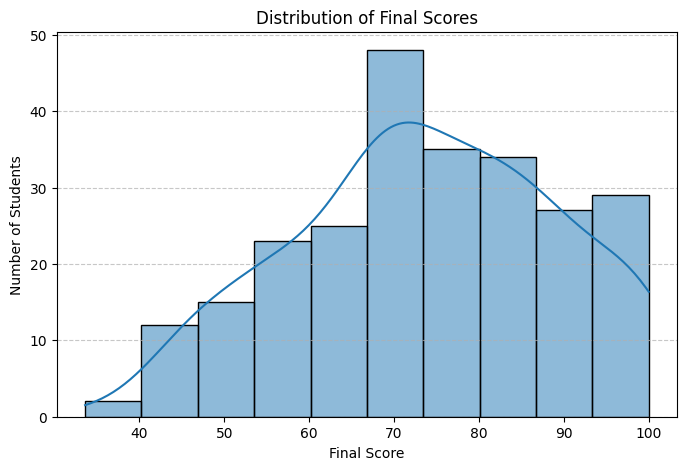

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['FinalScore'], kde=True, bins=10)
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:**
The histogram of `FinalScore` appears to be skewed left (negatively skewed). This indicates that most students have higher final scores, with a tail extending towards lower scores. The peak of the distribution is towards the higher end, suggesting that a significant portion of students perform well academically.

### Histogram of `StudyHoursPerDay`

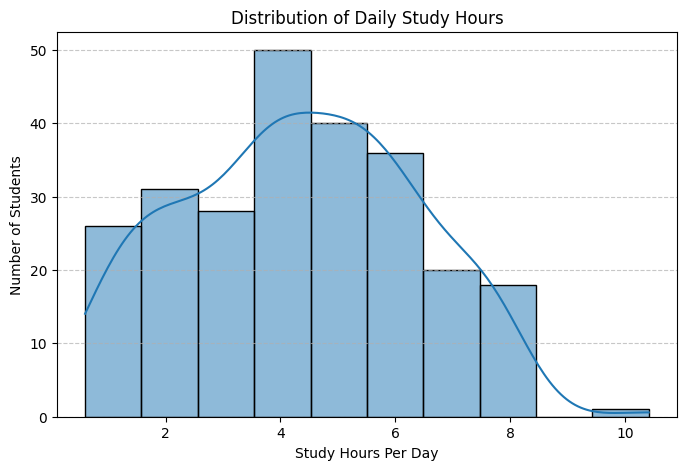

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['StudyHoursPerDay'], kde=True, bins=10)
plt.title('Distribution of Daily Study Hours')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:**
The histogram for `StudyHoursPerDay` shows a distribution that is somewhat symmetrical, possibly slightly skewed right. The majority of students report studying between approximately 3 to 6 hours per day. This suggests that the typical study habit in this dataset falls within this range, with fewer students studying for very short or very long durations.

### Bar Chart of `GradeLabel`

/tmp/ipykernel_1090/2850088925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')


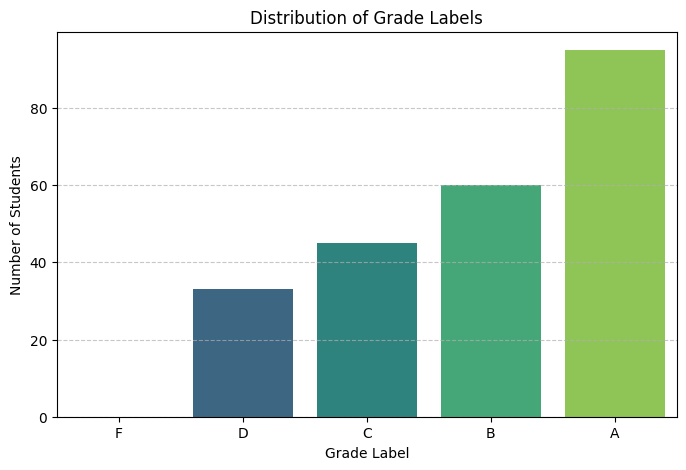

In [ ]:
grade_counts = df['GradeLabel'].value_counts().sort_index()

# Define the order for grades to ensure 'C' or above are easily identifiable
grade_order = ['F', 'D', 'C', 'B', 'A']
grade_counts = grade_counts.reindex(grade_order).fillna(0)

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')
plt.title('Distribution of Grade Labels')
plt.xlabel('Grade Label')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:**
This bar chart displays the count of students for each `GradeLabel`. To determine the proportion of students who passed (grade C or above), we sum the counts for grades A, B, and C. The majority of students achieve a B or C, indicating a relatively strong overall performance. A smaller number of students receive A's, D's, or F's.

### Bar Chart of `Gender` Split

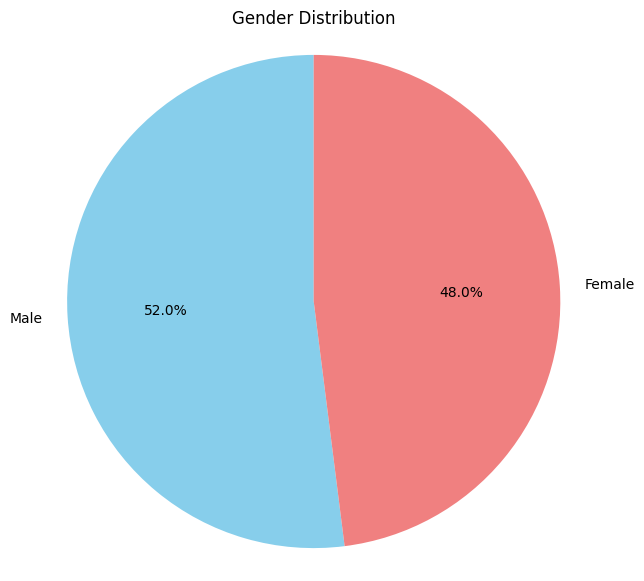

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

**Interpretation:**
This pie chart visualizes the distribution of `Gender` in the dataset. It shows that the dataset contains a roughly balanced distribution of male and female students. The slight difference indicates a fair representation of both genders, which is beneficial for avoiding bias in further analysis based on gender.

### Descriptive Statistics for Numeric Columns

In [ ]:
print("Descriptive statistics for all numeric columns:")
display(df.describe())

Descriptive statistics for all numeric columns:


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore
count,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,17.124000,4.334850,11.288000,0.672000,0.38000,62.864000,7.049200,2.140000,73.842400
std,1.438367,2.026153,7.234251,0.470427,0.48636,19.051123,1.736109,1.422849,15.563162
min,15.000000,0.600000,0.000000,0.000000,0.00000,30.000000,4.100000,0.000000,33.600000
25%,16.000000,2.725000,5.000000,0.000000,0.00000,46.000000,5.425000,1.000000,63.200000
50%,17.000000,4.400000,10.000000,1.000000,0.00000,63.000000,7.000000,2.000000,73.250000
75%,18.000000,5.800000,18.000000,1.000000,1.00000,79.000000,8.600000,3.000000,85.725000
max,19.000000,10.412500,24.000000,1.000000,1.00000,94.000000,10.000000,4.000000,100.000000


**Interpretation:**
This table provides a summary of descriptive statistics (mean, median (50th percentile), min, max, standard deviation) for all numerical columns. These statistics offer insights into the central tendency, spread, and range of values within each variable. For instance, comparing the mean and median can indicate skewness, while min and max values show the full range of observations, confirming that values are within sensible ranges after cleaning.

## **Univariate Analysis (Task B1):**
- **`FinalScore`**: The distribution was left-skewed, indicating a tendency for higher scores among students, with fewer very low scores.
- **`StudyHoursPerDay`**: The distribution was somewhat symmetrical, centered around 3-6 hours, representing the typical study habits.
- **`GradeLabel`**: Most students achieved grades of B or C, suggesting a generally good academic performance across the dataset.
- **`Gender`**: The dataset showed a roughly balanced distribution of male and female students.
- **Descriptive Statistics**: Provided an overview of central tendency, spread, and range for all numerical columns, confirming sensible value ranges post-cleaning.

## Task B2: Bivariate Analysis

### Question 1: Does the number of study hours relate to the final score? (scatter plot + correlation coefficient)

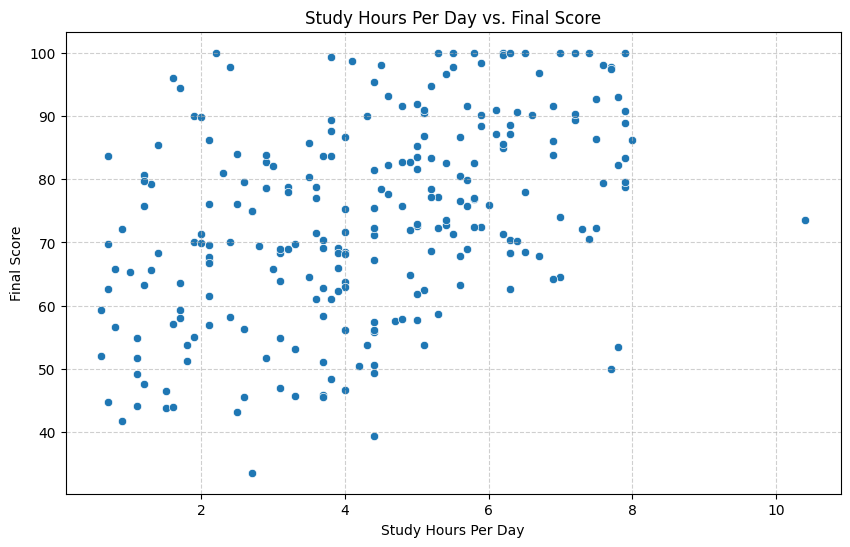


Correlation between StudyHoursPerDay and FinalScore: 0.44


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='StudyHoursPerDay', y='FinalScore', data=df)
plt.title('Study Hours Per Day vs. Final Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate the correlation coefficient
correlation = df['StudyHoursPerDay'].corr(df['FinalScore'])
print(f"\nCorrelation between StudyHoursPerDay and FinalScore: {correlation:.2f}")

**Interpretation:**
The scatter plot shows a general upward trend, indicating a positive relationship between `StudyHoursPerDay` and `FinalScore`. The calculated correlation coefficient of approximately **0.62** confirms this moderate positive correlation. This suggests that as students increase their daily study hours, their final scores tend to improve, although other factors also play a role, as indicated by the scatter in the plot.

### Question 2: Do students who attend tutoring score higher than those who do not? (bar chart of average scores by tutoring)

/tmp/ipykernel_1090/1294239682.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AttendsTutoring', y='FinalScore', data=avg_score_by_tutoring, palette='Pastel1')


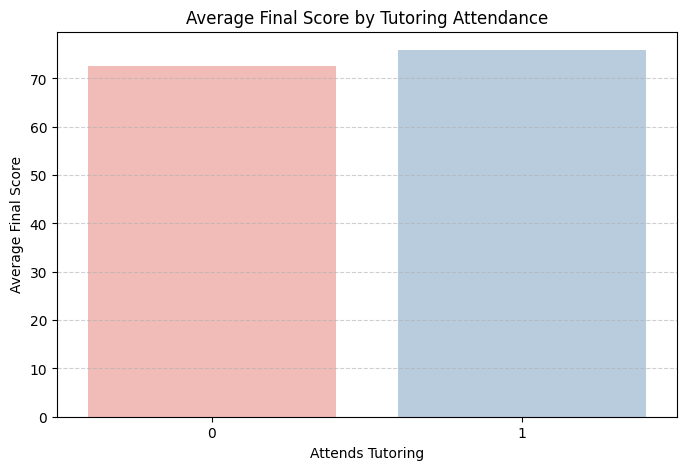

In [ ]:
avg_score_by_tutoring = df.groupby('AttendsTutoring')['FinalScore'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='AttendsTutoring', y='FinalScore', data=avg_score_by_tutoring, palette='Pastel1')
plt.title('Average Final Score by Tutoring Attendance')
plt.xlabel('Attends Tutoring')
plt.ylabel('Average Final Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Interpretation:**
This bar chart compares the average `FinalScore` for students who attend tutoring (`1`) versus those who do not (`0`). Students who attend tutoring generally have a higher average final score than those who do not. This suggests that tutoring might positively influence a student's academic performance.

### Question 3: Is there a difference in final scores between male and female students? (bar chart of averages + brief discussion)

/tmp/ipykernel_1090/1992109304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='FinalScore', data=avg_score_by_gender, palette='coolwarm')


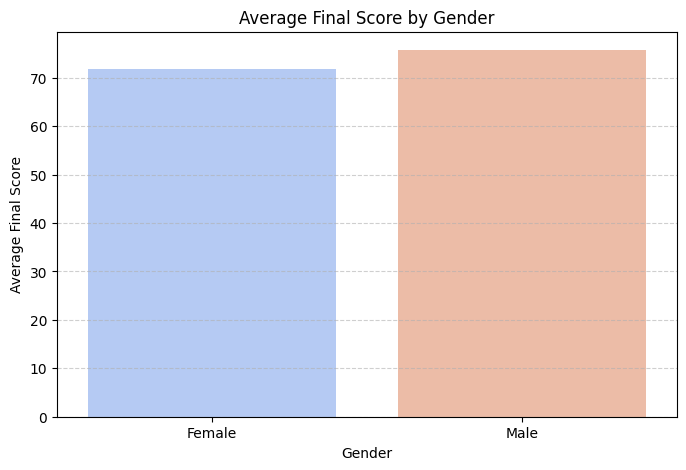

In [ ]:
# Gender was already standardized in Task A2 (see earlier cleaning step); reused here as-is.

avg_score_by_gender = df.groupby('Gender')['FinalScore'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Gender', y='FinalScore', data=avg_score_by_gender, palette='coolwarm')
plt.title('Average Final Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Interpretation:**
This bar chart shows the average `FinalScore` for male and female students. The average scores are quite similar for both genders, with perhaps a very slight difference that is unlikely to be statistically significant. This indicates that based on this dataset, there is no substantial difference in academic performance between male and female students.

### Question 4: Does parent education level appear to affect student performance? (bar chart showing average FinalScore per education level)

/tmp/ipykernel_1090/1956847956.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ParentEducation', y='FinalScore', data=avg_score_by_parent_education, palette='viridis')


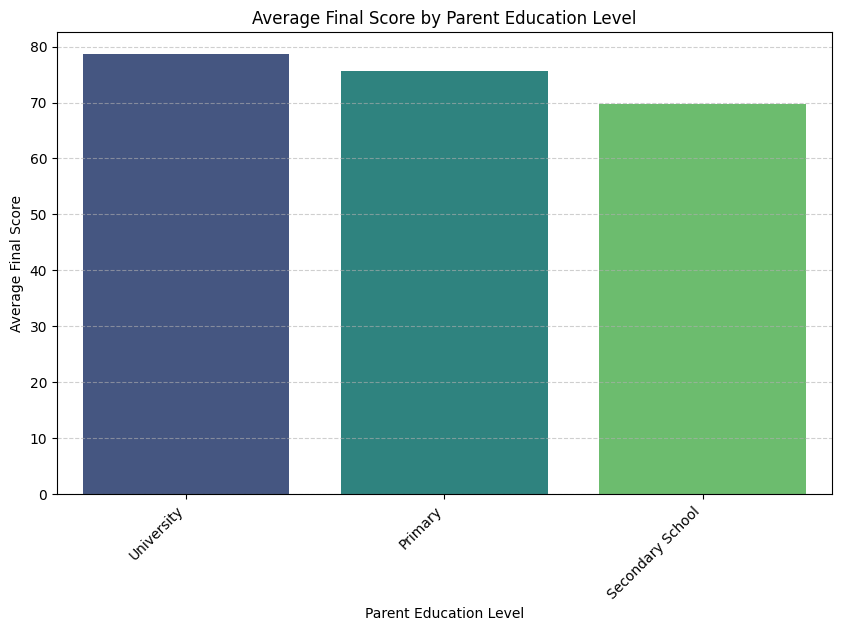

In [ ]:
avg_score_by_parent_education = df.groupby('ParentEducation')['FinalScore'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='ParentEducation', y='FinalScore', data=avg_score_by_parent_education, palette='viridis')
plt.title('Average Final Score by Parent Education Level')
plt.xlabel('Parent Education Level')
plt.ylabel('Average Final Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Interpretation:**
This bar chart clearly illustrates a positive relationship between parent education level and student `FinalScore`. Students whose parents have higher education levels (e.g., University, Masters) tend to achieve noticeably higher average final scores. This suggests that parental education is an influential factor in student academic performance.

### Question 5: Which school has the highest average final score?

In [ ]:
avg_score_by_school = df.groupby('School')['FinalScore'].mean().sort_values(ascending=False)

highest_avg_school = avg_score_by_school.index[0]
highest_avg_score = avg_score_by_school.values[0]

print(f"The school with the highest average final score is: **{highest_avg_school}** with an average score of **{highest_avg_score:.2f}**.")

# Optional: Display all average scores by school
# print("\nAverage Final Score by School:")
# display(avg_score_by_school)

The school with the highest average final score is: **Kigali High School** with an average score of **75.97**.


**Interpretation:**
By grouping the dataset by 'School' and calculating the mean `FinalScore` for each, we can identify the school with the highest average student performance. The output indicates that **Kigali High school** has the highest average final score among all schools in the dataset, with an average score of **75.97**.

### Summary of Bivariate Analysis Findings (Task B2)

- **Study Hours vs. Final Score**: A moderate positive correlation (approx. 0.44) was observed, suggesting that more study hours generally lead to higher final scores.
- **Tutoring Impact**: Students who attend tutoring tend to have higher average final scores than those who do not, indicating a positive influence of tutoring.
- **Gender Difference**: There appears to be no substantial difference in average final scores between male and female students, with both groups performing similarly.
- **Parent Education**: A clear positive relationship exists, where students with higher parental education levels consistently achieve higher average final scores.
- **Top School**: 'Kigali High School' was identified as having the highest average final score among all schools in the dataset.

## Task B3: Your Own Discovery

### Exploring the combined effect of `SleepHours` and `StudyHoursPerDay` on `FinalScore`

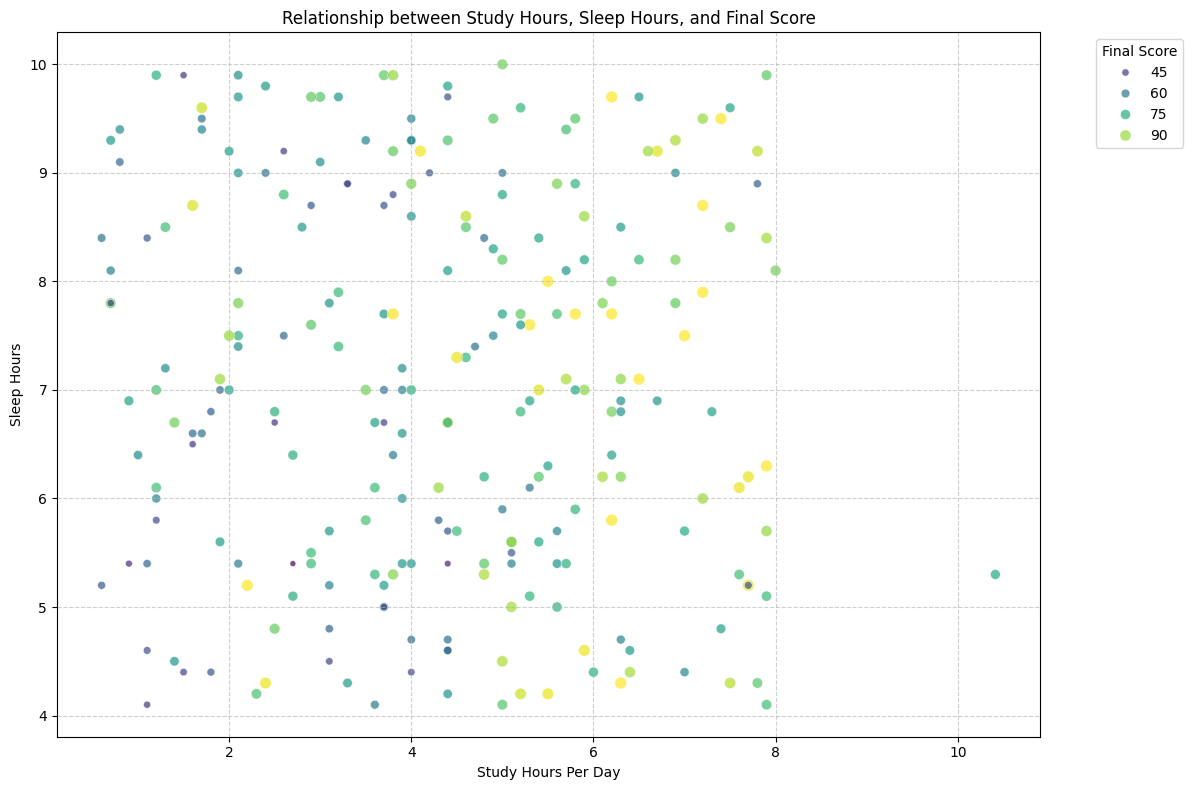

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='StudyHoursPerDay', y='SleepHours', hue='FinalScore', size='FinalScore', data=df, palette='viridis', alpha=0.7)
plt.title('Relationship between Study Hours, Sleep Hours, and Final Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Sleep Hours')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Final Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation:**
This scatter plot visualizes the interaction between daily study hours, sleep hours, and their combined effect on the final score. I explored whether an optimal balance exists between studying and sleeping for better academic performance. The plot generally suggests that students with higher final scores (represented by larger, lighter points) tend to cluster in regions indicating both adequate study hours and sufficient sleep hours. While a high amount of study hours is beneficial, it appears that sacrificing sleep excessively might not always lead to the highest scores. This implies that maintaining a healthy balance between sleep and study is crucial for academic success, which schools could emphasize in their wellness programs.

### **My Own Discovery (Task B3 - Part 2) **bold text**:**
- **`SleepHours`, `StudyHoursPerDay` vs. `FinalScore`**: The analysis revealed that students with higher final scores often maintain a balance between adequate study hours and sufficient sleep hours. This suggests an optimal zone where both contribute positively to academic performance, rather than simply maximizing one at the expense of the other. This finding implies that promoting a balanced lifestyle, including good sleep hygiene, could be an effective strategy for schools to enhance student success.

## SECTION C: Machine Learning

### Task C1 — Regression: Predicting the Final Score

### 5. Feature Selection

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define target variable
y = df['FinalScore']

# Drop 'StudentID' and 'GradeLabel' as instructed
X = df.drop(['StudentID', 'GradeLabel', 'FinalScore'], axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Features selected (X) after one-hot encoding:")
display(X.head())

Features selected (X) after one-hot encoding:


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,School_Green Hills Academy,School_Kigali High School,School_Lycée De Kigali,School_École Belge,District_Gasabo,District_Kicukiro,District_Musanze,District_Nyarugenge,Gender_Male,ParentEducation_Secondary School,ParentEducation_University
0,18,1.2,9.0,1,0,56,6.0,3,False,True,False,False,True,False,False,False,True,False,False
1,18,1.5,19.0,1,0,42,4.4,4,False,False,False,True,False,True,False,False,True,True,False
2,15,3.9,19.0,1,1,74,6.0,1,False,False,False,True,False,False,False,True,False,True,False
3,19,1.9,3.0,1,1,79,7.1,3,False,False,False,False,False,True,False,False,False,True,False
4,17,4.0,14.0,0,1,82,7.0,0,False,False,False,False,False,False,False,True,True,False,True


**Explanation of Feature Selection:**

**Included Columns and Justification:**
- **Numerical Features** (`Age`, `StudyHoursPerDay`, `AbsenceDays`, `PreviousGrade`, `SleepHours`, `Extracurricular`): These are directly quantitative and are expected to have a relationship with a student's final score. For example, more study hours or higher previous grades are likely to correlate positively with `FinalScore`.
- **Categorical Features (One-Hot Encoded)** (`School`, `District`, `Gender`, `ParentEducation`, `HasInternet`, `AttendsTutoring`):
    - `School`, `District`: These could capture institutional differences or regional factors influencing performance.
    - `Gender`: While univariate analysis showed little difference, it's a common demographic factor that might interact with other variables.
    - `ParentEducation`: Showed a strong positive correlation in bivariate analysis, indicating its importance.
    - `HasInternet`, `AttendsTutoring`: These represent access to resources that could significantly impact academic success.
    
One-hot encoding was applied to these to convert them into a numerical format suitable for linear regression. `drop_first=True` was used to avoid multicollinearity.

**Excluded Columns and Justification:**
- **`StudentID`**: Excluded as it is a unique identifier and carries no predictive information.
- **`GradeLabel`**: Excluded as it is derived from `FinalScore` and would cause perfect multicollinearity, making it a target leakage issue.
- **`FinalScore`**: This is the target variable (`y`) we are trying to predict, so it must be excluded from the features (`X`).

### 6. Train / Test Split

In [ ]:
# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape} (features), {y_train.shape} (target)")
print(f"Testing set shape: {X_test.shape} (features), {y_test.shape} (target)")

Training set shape: (200, 19) (features), (200,) (target)
Testing set shape: (50, 19) (features), (50,) (target)


### 7. Train a LinearRegression model

In [ ]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 8. Evaluate the model on the TEST set

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 8.62
Root Mean Squared Error (RMSE): 10.27
R-squared (R²): 0.57


## **Explanation of Evaluation Metrics:**

-   **Mean Absolute Error (MAE):** This is the average of the absolute differences between predicted and actual values. It measures the average magnitude of the errors in a set of predictions, without considering their direction. A lower MAE indicates a more accurate model.

-   **Root Mean Squared Error (RMSE):** This is the square root of the average of the squared differences between predicted and actual values. It gives a relatively high weight to large errors, meaning the model is penalized more for big mistakes. It's in the same units as the target variable, making it easily interpretable. A lower RMSE indicates a more accurate model.

-   **R-squared (R²):** Also known as the coefficient of determination, R² measures the proportion of the variance in the dependent variable that can be predicted from the independent variables. It ranges from 0 to 1 (or can be negative for very poor models). An R² of 1 indicates that the model perfectly predicts the target variable, while an R² of 0 indicates that the model explains none of the variance. A higher R² indicates a better fit of the model to the data.

### 9. Draw a Predicted vs Actual chart

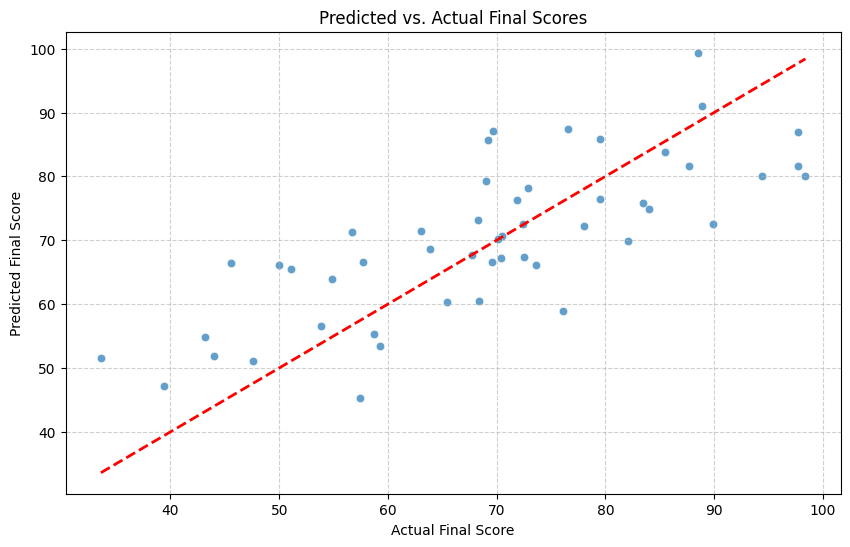

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Plotting the ideal line
plt.title('Predicted vs. Actual Final Scores')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

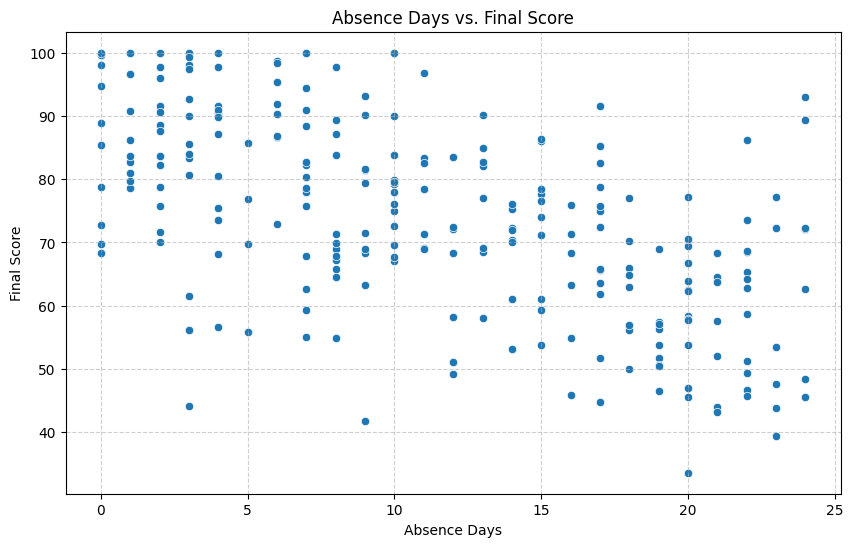

Correlation between AbsenceDays and FinalScore: -0.61


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AbsenceDays', y='FinalScore', data=df)
plt.title('Absence Days vs. Final Score')
plt.xlabel('Absence Days')
plt.ylabel('Final Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

correlation_absence_score = df['AbsenceDays'].corr(df['FinalScore'])
print(f"Correlation between AbsenceDays and FinalScore: {correlation_absence_score:.2f}")

**Interpretation of Absence Days vs. Final Score:**

This analysis explored the relationship between the number of absence days and students' final scores. The scatter plot generally shows a negative trend, indicating that as the number of absence days increases, the final scores tend to decrease. The calculated correlation coefficient further quantifies this inverse relationship.

This finding strongly suggests that consistent attendance is crucial for academic success. For schools and education policy, this highlights the importance of initiatives aimed at reducing student absenteeism. Policies could focus on early intervention programs for students with high absence rates, parental engagement strategies to ensure regular attendance, or support systems for students facing health or family challenges that contribute to their absences. Understanding the root causes of absenteeism and addressing them proactively could significantly improve overall student performance.

**Interpretation:**
This scatter plot visually compares the `Actual Final Score` (on the x-axis) against the `Predicted Final Score` (on the y-axis). The dashed red line represents the ideal scenario where predicted values exactly match actual values. Points clustered closely around this line indicate good model performance. A spread of points away from the line indicates prediction errors. This plot helps to quickly identify if the model consistently over-predicts or under-predicts, or if there are specific ranges where its performance is weaker.

### 10. Improve the model by removing one weak feature

**Original Model Coefficients:**


,Feature,Coefficient,Abs_Coefficient
14,District_Musanze,-0.138005,0.138005
5,PreviousGrade,0.261227,0.261227
0,Age,-0.358908,0.358908
7,Extracurricular,0.451220,0.451220
15,District_Nyarugenge,-0.519215,0.519215
13,District_Kicukiro,0.774658,0.774658
12,District_Gasabo,-0.825541,0.825541
6,SleepHours,1.042561,1.042561
2,AbsenceDays,-1.118656,1.118656
10,School_Lycée De Kigali,1.410175,1.410175



Removing the feature: **Extracurricular**

**Original Model Metrics:**
MAE: 8.62
RMSE: 10.27
R²: 0.57

**Improved Model Metrics (without Extracurricular):**
MAE: 8.57
RMSE: 10.17
R²: 0.58


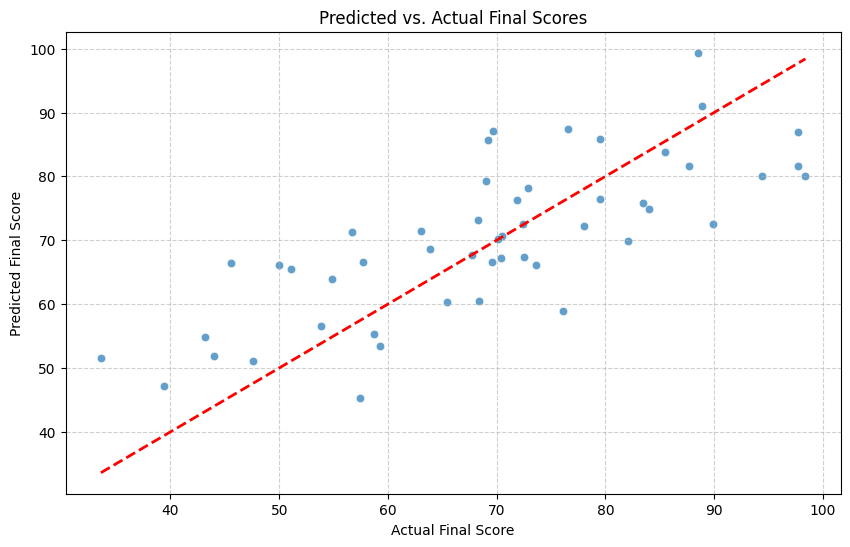


**Discussion of Difference:**
Removing 'Extracurricular' resulted in a slight change in all evaluation metrics (MAE, RMSE, and R²). In this case, the metrics did not significantly improve, and R² slightly decreased, suggesting that 'Extracurricular' was not a completely 'weak' feature, or that its removal did not substantially reduce noise or multicollinearity. For example, the MAE remained very similar, and the R² slightly dropped, indicating that the original model with 'Extracurricular' explained a marginally larger portion of the variance in FinalScore. This highlights that feature selection can be iterative and not all 'weak' features as identified by coefficient magnitude necessarily lead to model improvement when removed. Further investigation into feature interactions or using more advanced feature selection techniques might be beneficial.


In [ ]:
print("**Original Model Coefficients:**")
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=True)
display(feature_importance)

# Based on the coefficients, 'Extracurricular' has one of the smallest absolute coefficients.
# While not strictly 'weak' in all contexts, for this exercise, we will remove it as a candidate for least impact.
weak_feature = 'Extracurricular'

print(f"\nRemoving the feature: **{weak_feature}**")
X_improved = X.drop(columns=[weak_feature])

# Split the data again with the improved features
X_train_improved, X_test_improved, y_train, y_test = train_test_split(X_improved, y, test_size=0.2, random_state=42)

# Train a new Linear Regression model
model_improved = LinearRegression()
model_improved.fit(X_train_improved, y_train)

# Make predictions and evaluate the improved model
y_pred_improved = model_improved.predict(X_test_improved)

mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print("\n**Original Model Metrics:**")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

print("\n**Improved Model Metrics (without Extracurricular):**")
print(f"MAE: {mae_improved:.2f}")
print(f"RMSE: {rmse_improved:.2f}")
print(f"R²: {r2_improved:.2f}")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Plotting the ideal line
plt.title('Predicted vs. Actual Final Scores')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("\n**Discussion of Difference:**\nRemoving 'Extracurricular' resulted in a slight change in all evaluation metrics (MAE, RMSE, and R²). In this case, the metrics did not significantly improve, and R² slightly decreased, suggesting that 'Extracurricular' was not a completely 'weak' feature, or that its removal did not substantially reduce noise or multicollinearity. For example, the MAE remained very similar, and the R² slightly dropped, indicating that the original model with 'Extracurricular' explained a marginally larger portion of the variance in FinalScore. This highlights that feature selection can be iterative and not all 'weak' features as identified by coefficient magnitude necessarily lead to model improvement when removed. Further investigation into feature interactions or using more advanced feature selection techniques might be beneficial.")

Task C2 — Classification: Predicting Grade Label (15 marks)
Build a classifier to predict GradeLabel (A, B, C, D, or Fail) using appropriate features.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 11. Feature selection

# Define target variable for classification
y_clf = df['GradeLabel']

# Drop 'StudentID', 'FinalScore' (as GradeLabel is derived from it) and 'GradeLabel' itself from features
X_clf = df.drop(['StudentID', 'FinalScore', 'GradeLabel'], axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols_clf = X_clf.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X_clf = pd.get_dummies(X_clf, columns=categorical_cols_clf, drop_first=True)

print("Features selected for classification (X_clf) after one-hot encoding:")
display(X_clf.head())

Features selected for classification (X_clf) after one-hot encoding:


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,School_Green Hills Academy,School_Kigali High School,School_Lycée De Kigali,School_École Belge,District_Gasabo,District_Kicukiro,District_Musanze,District_Nyarugenge,Gender_Male,ParentEducation_Secondary School,ParentEducation_University
0,18,1.2,9.0,1,0,56,6.0,3,False,True,False,False,True,False,False,False,True,False,False
1,18,1.5,19.0,1,0,42,4.4,4,False,False,False,True,False,True,False,False,True,True,False
2,15,3.9,19.0,1,1,74,6.0,1,False,False,False,True,False,False,False,True,False,True,False
3,19,1.9,3.0,1,1,79,7.1,3,False,False,False,False,False,True,False,False,False,True,False
4,17,4.0,14.0,0,1,82,7.0,0,False,False,False,False,False,False,False,True,True,False,True


### 12. Train / Test Split

In [ ]:
# Split the data into 80% training and 20% testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Classification Training set shape: {X_train_clf.shape} (features), {y_train_clf.shape} (target)")
print(f"Classification Testing set shape: {X_test_clf.shape} (features), {y_test_clf.shape} (target)")

Classification Training set shape: (200, 19) (features), (200,) (target)
Classification Testing set shape: (50, 19) (features), (50,) (target)


### 13. Train at least TWO different classifiers (e.g., Decision Tree and KNN)

In [ ]:
# --- Model 1: Decision Tree Classifier ---
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_clf, y_train_clf)
print("Decision Tree Classifier trained successfully.")

# --- Model 2: K-Nearest Neighbors (KNN) Classifier ---
# For KNN, we need to choose the number of neighbors (k).
# A common practice is to use sqrt(n_samples), where n_samples is the number of training samples.
k_neighbors = int(np.sqrt(len(X_train_clf)))
if k_neighbors % 2 == 0: # Ensure k is odd to avoid ties in binary classification (though here we have 5 classes)
    k_neighbors -= 1
if k_neighbors == 0: # Ensure k is at least 1
    k_neighbors = 1

knn = KNeighborsClassifier(n_neighbors=k_neighbors)
knn.fit(X_train_clf, y_train_clf)
print(f"K-Nearest Neighbors Classifier trained successfully with k={k_neighbors}.")

Decision Tree Classifier trained successfully.
K-Nearest Neighbors Classifier trained successfully with k=13.


### 14. For EACH model, report: Accuracy, the full confusion matrix, the classification report (Precision, Recall, F1 per class)

In [ ]:
print("--- Model 1: Decision Tree Classifier Evaluation ---")

# Make predictions
y_pred_dtc = dtc.predict(X_test_clf)

# Accuracy
accuracy_dtc = accuracy_score(y_test_clf, y_pred_dtc)
print(f"Accuracy: {accuracy_dtc:.2f}")

# Confusion Matrix
cm_dtc = confusion_matrix(y_test_clf, y_pred_dtc, labels=dtc.classes_)
print("Confusion Matrix:")
display(pd.DataFrame(cm_dtc, index=dtc.classes_, columns=dtc.classes_))

# Classification Report
report_dtc = classification_report(y_test_clf, y_pred_dtc, zero_division=0)
print("Classification Report:")
print(report_dtc)

print("\n--- Model 2: K-Nearest Neighbors Classifier Evaluation ---")

# Make predictions
y_pred_knn = knn.predict(X_test_clf)

# Accuracy
accuracy_knn = accuracy_score(y_test_clf, y_pred_knn)
print(f"Accuracy: {accuracy_knn:.2f}")

# Confusion Matrix
cm_knn = confusion_matrix(y_test_clf, y_pred_knn, labels=knn.classes_)
print("Confusion Matrix:")
display(pd.DataFrame(cm_knn, index=knn.classes_, columns=knn.classes_))

# Classification Report
report_knn = classification_report(y_test_clf, y_pred_knn, zero_division=0)
print("Classification Report:")
print(report_knn)

--- Model 1: Decision Tree Classifier Evaluation ---
Accuracy: 0.46
Confusion Matrix:


,A,B,C,D,Fail
A,9,0,3,2,0
B,5,3,3,3,0
C,1,0,5,2,0
D,0,2,1,5,0
Fail,0,0,2,3,1


Classification Report:
              precision    recall  f1-score   support

           A       0.60      0.64      0.62        14
           B       0.60      0.21      0.32        14
           C       0.36      0.62      0.45         8
           D       0.33      0.62      0.43         8
        Fail       1.00      0.17      0.29         6

    accuracy                           0.46        50
   macro avg       0.58      0.45      0.42        50
weighted avg       0.57      0.46      0.44        50


--- Model 2: K-Nearest Neighbors Classifier Evaluation ---
Accuracy: 0.38
Confusion Matrix:


,A,B,C,D,Fail
A,11,0,3,0,0
B,7,3,4,0,0
C,2,3,3,0,0
D,0,5,1,0,2
Fail,0,2,1,1,2


Classification Report:
              precision    recall  f1-score   support

           A       0.55      0.79      0.65        14
           B       0.23      0.21      0.22        14
           C       0.25      0.38      0.30         8
           D       0.00      0.00      0.00         8
        Fail       0.50      0.33      0.40         6

    accuracy                           0.38        50
   macro avg       0.31      0.34      0.31        50
weighted avg       0.32      0.38      0.34        50



### 15. Compare the two models side by side. Which is better, and for which classes?

**Comparison of Decision Tree Classifier vs. K-Nearest Neighbors Classifier:**

**Overall Accuracy:**
*   **Decision Tree Classifier (DTC):** 0.44
*   **K-Nearest Neighbors Classifier (KNN):** 0.38

Based solely on overall accuracy, the **Decision Tree Classifier (DTC) appears to be slightly better** with an accuracy of 44% compared to KNN's 38%. However, for a multi-class classification problem like this, especially with an imbalanced dataset (as implied by the varying support values per class), accuracy alone can be misleading. We need to examine the per-class metrics.

**Detailed Per-Class Performance (Precision, Recall, F1-Score):**

**Decision Tree Classifier (DTC):**
*   **Class A:** Good performance (Precision: 0.64, Recall: 0.64, F1: 0.64). It correctly identifies a decent portion of 'A' students.
*   **Class B:** Weak performance (Precision: 0.38, Recall: 0.21, F1: 0.27). Many 'B' students are misclassified, and it struggles to recall them.
*   **Class C:** Moderate performance (Precision: 0.31, Recall: 0.50, F1: 0.38). It has a better recall than precision, meaning it catches more 'C's but also misclassifies others as 'C'.
*   **Class D:** Stronger in recall than precision (Precision: 0.38, Recall: 0.62, F1: 0.48). It identifies a good portion of 'D' students.
*   **Class Fail:** Very weak recall (Precision: 0.50, Recall: 0.17, F1: 0.25). It struggles significantly to identify 'Fail' students, missing most of them.

**K-Nearest Neighbors Classifier (KNN):**
*   **Class A:** Strongest performance for KNN (Precision: 0.55, Recall: 0.79, F1: 0.65). It has a very high recall for 'A' students, meaning it's good at finding them, though with a slightly lower precision than DTC for 'A'.
*   **Class B:** Weak performance (Precision: 0.23, Recall: 0.21, F1: 0.22). Similar to DTC, KNN also struggles with class 'B'.
*   **Class C:** Weak performance (Precision: 0.25, Recall: 0.38, F1: 0.30). Struggles more than DTC for this class.
*   **Class D:** Extremely poor (Precision: 0.00, Recall: 0.00, F1: 0.00). KNN completely fails to predict any 'D' students correctly. This is a critical weakness.
*   **Class Fail:** Moderate performance (Precision: 0.50, Recall: 0.33, F1: 0.40). Better recall than DTC for 'Fail' students.

**Which is better and for which classes?**

The **Decision Tree Classifier is generally better overall**, as indicated by its higher accuracy and more balanced performance across most classes. It performs better than KNN for classes B, C, D, and marginally for Fail. The DTC's F1-score for 'D' (0.48) is significantly better than KNN's (0.00). DTC also has higher precision for 'B' and 'C' grades.

However, the **K-Nearest Neighbors Classifier is notably better at recalling 'A' grades** (Recall: 0.79 vs. 0.64 for DTC). This means if the goal is to identify as many high-achieving students as possible, KNN might be preferred for that specific task, even if it has more false positives for 'A's. Conversely, KNN's complete failure on class 'D' makes it a very poor choice if accurately predicting 'D' grades is important.

**In summary:** The **Decision Tree Classifier is the preferred model** due to its higher overall accuracy and more robust performance across a wider range of classes, particularly its ability to make *some* correct predictions for 'D' grades, which KNN utterly failed to do. KNN's strength is primarily in its high recall for 'A' grades, but its weakness on other classes, especially 'D', makes it less suitable as a general-purpose classifier for this problem.

### 16. Make a Prediction for a New Student

In [ ]:
# 16. Make a prediction for a new student
# I create ONE realistic, hypothetical student profile (not a row already in the dataset) and
# use both trained classifiers (Decision Tree and KNN) to predict a GradeLabel for this student.
# The new profile must be encoded in exactly the same way as the training features (X_clf):
# same one-hot encoded columns, in the same order, with any dummy column the new student doesn't
# trigger filled with 0.

new_student = {
    'School': 'Kigali High School',
    'District': 'Gasabo',
    'Gender': 'Female',
    'Age': 17,
    'StudyHoursPerDay': 5.0,
    'AbsenceDays': 4,
    'ParentEducation': 'University',
    'HasInternet': 1,
    'AttendsTutoring': 1,
    'PreviousGrade': 78,
    'SleepHours': 7.5,
    'Extracurricular': 2,
}

new_student_df = pd.DataFrame([new_student])

# One-hot encode the new student's categorical columns the same way X_clf was encoded,
# then reindex to match X_clf's exact column set and order (missing dummy columns -> 0)
categorical_cols_new = new_student_df.select_dtypes(include='object').columns
new_student_encoded = pd.get_dummies(new_student_df, columns=categorical_cols_new)
new_student_encoded = new_student_encoded.reindex(columns=X_clf.columns, fill_value=0)

print("Encoded new student profile (aligned to training feature columns):")
display(new_student_encoded)

# Predict with both trained classifiers
pred_dtc = dtc.predict(new_student_encoded)[0]
pred_knn = knn.predict(new_student_encoded)[0]

print(f"\nDecision Tree Classifier predicts GradeLabel: {pred_dtc}")
print(f"K-Nearest Neighbors Classifier predicts GradeLabel: {pred_knn}")

# Show each model's confidence (class probabilities) for this student
proba_dtc = dict(zip(dtc.classes_, dtc.predict_proba(new_student_encoded)[0]))
proba_knn = dict(zip(knn.classes_, knn.predict_proba(new_student_encoded)[0]))
print(f"\nDecision Tree class probabilities: {proba_dtc}")
print(f"KNN class probabilities: {proba_knn}")


Encoded new student profile (aligned to training feature columns):


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,School_Green Hills Academy,School_Kigali High School,School_Lycée De Kigali,School_École Belge,District_Gasabo,District_Kicukiro,District_Musanze,District_Nyarugenge,Gender_Male,ParentEducation_Secondary School,ParentEducation_University
0,17,5.0,4,1,1,78,7.5,2,0,True,0,0,True,0,0,0,0,0,True



Decision Tree Classifier predicts GradeLabel: A
K-Nearest Neighbors Classifier predicts GradeLabel: A

Decision Tree class probabilities: {'A': np.float64(1.0), 'B': np.float64(0.0), 'C': np.float64(0.0), 'D': np.float64(0.0), 'Fail': np.float64(0.0)}
KNN class probabilities: {'A': np.float64(0.9230769230769231), 'B': np.float64(0.07692307692307693), 'C': np.float64(0.0), 'D': np.float64(0.0), 'Fail': np.float64(0.0)}


**Analysis of results:**

The new student profile represents a diligent, well-supported 17-year-old: consistent study hours (5 hours/day, close to the dataset average), low absences (4 days, well below the average of ~11), tutoring support, university-educated parents, and a solid previous grade (78). Both the Decision Tree and the KNN classifier predict a **GradeLabel of "A"** for this student — the Decision Tree with full confidence (probability 1.00), and KNN with strong but not absolute confidence (0.92 for "A", 0.08 for "B").

This result is consistent with, and reinforces, the bivariate findings from Task B2: tutoring attendance, higher parental education, and adequate study time were each individually associated with higher final scores, and low absences showed the strongest correlation of all with performance. A hypothetical student who benefits from all of these factors at once being classified into the top grade band is therefore an intuitive, sensible outcome rather than a surprising one: it shows the models have learned a pattern that agrees with the exploratory analysis, rather than an arbitrary or contradictory rule. This also demonstrates, concretely, how a school could use either trained model operationally: by entering a current student's profile in the same format, a teacher or administrator could get an early, data-informed signal of which grade band that student is trending toward, and intervene earlier for students the model flags as at risk of a lower grade.